In [5]:
import torch
import torch.nn as nn 
import numpy as np
import matplotlib.pyplot as plt 
import numpy as np 
import time 
import os
import sys
import pandas as pd 

In [6]:
from scipy.optimize import minimize
import numpy as np

In [7]:
torch.set_default_dtype(torch.float32)

In [8]:
class SDE1(object):
    def __init__(self, T=1.0, σ=0.5,N=20,batch_size=16): 
        self.T=T
        self.sigma=σ
        self.dim=2
        self.N=N; 
        self.dt=self.T/self.N
        self.batch_size=batch_size
        self.x0=1.0

    def drift(self,t,xvec, utensor, return_vals='b'): 
        """
        In the case where u is only deterministic, u is only of dimenson 2. 
        
        uvec is in the batch mode
        
        """
        
   #     def beta(t,T,σ): 
   #         op=(1.0+σ**2)+σ**2*(T-t)
   #         return op

       # beta_t=beta(t,self.T, self.sigma)
       # r1=-t**2/2.0/beta_t
       # r2=-np.sin(t)/beta_t
       # rvec=np.array([r1,r2])
        
        b=utensor*xvec
         
        return b#,rvec
    
    def diffusion(self,xvec):
        """"
        uvec is in the batch mode
        
        """
        sig = self.sigma*xvec
       # np.multiply(a,b)
        return sig

    def generate_SDE(self,Utensor):
        """
        Utensor is not a list
        x0 is 1
        """
        x0=np.ones((self.batch_size, self.dim))
        xlist=list()
        wlist=list()
       # w2list=list() ## the 
  
        tvec=np.arange(0,self.T,self.T/self.N) #length N
        
        xlist.append(x0)
        rvec_list=list()
        for i in range(0,self.N):
            dw=np.sqrt(self.dt)*np.random.randn(*x0.shape)
            b_out=self.drift(tvec[i],xlist[-1], Utensor[i])
            xtemp=xlist[-1]+ b_out *self.dt+ self.diffusion(xlist[-1])*dw
            xlist.append(xtemp)
            wlist.append(dw)
         #   rvec_list.append(r_out)

      #  self.rlist=rvec_list

        return xlist, wlist

    def generate_SDE_Horder(self,Utensor):
        x0=np.ones((self.batch_size, self.dim))
        xlist=list()
        wlist=list()
        w2list=list() ## the 

        tvec=np.arange(0,self.T,self.T/self.N) #length N
        
        xlist.append(x0)
        rvec_list=list()

        dt1_s,dt2_s=np.sqrt(self.dt), np.sqrt((self.dt)**3/3.0) 

        def dWdZ(x0,dt1_s, dt2_s):
            w1_norm=np.random.randn(*x0.shape)
            w2_norm=np.random.randn(*x0.shape)

            z_aux=(0.5*w1_norm+np.sqrt(3.0)/2.0*w2_norm)*dt2_s
            w_out=w2_norm*dt1_s
            return w_out,z_aux

        for i in range(0,self.N):
            w_out, z_aux=dWdZ(x0,dt1_s, dt2_s) ## generate the input variables 
      
            b0= self.drift(tvec[i],xlist[-1], Utensor[i])
            b_prime=Utensor[i]
            
            sig0=self.diffusion(xlist[-1])
            sig_prime=self.sigma

            
            p1=b0 *self.dt+ sig0*w_out
            p2= 0.5*sig0*sig_prime*( w_out**2 - self.dt) 
            p3= sig0*sig_prime*z_aux+0.5*b0*b_prime*(self.dt)**2
            p4= b0*sig_prime*(w_out*self.dt-z_aux)
            p5= 0.5*sig0*self.sigma**2*(1.0/3.0*w_out**2 - self.dt)*w_out 

            
            xtemp=xlist[-1]+ p1+p2 + p3 + p4+ p5
            xlist.append(xtemp)
            wlist.append(w_out)
        return xlist, wlist

    def init_utensor1(self):
        u0=np.zeros([self.dim])
        Uvec=list()
        for i in range(self.N):
            Uvec.append(np.zeros([self.dim]))
        return np.array(Uvec)

    def Uvec(self):
        tvec=np.arange(0,self.T,self.T/self.N) #length N
        arg=1.0+(self.sigma**2 * self.T)/(1.0+self.sigma**2)
        D=np.log(arg)/(self.sigma**2+np.log(arg))
        
        x1T=self.T**2/2.0*D
        x2T=np.sin(self.T)*D

        def beta1(t,T,σ): 
            op=1.0/self.x0-T*t+0.5*t**2
            return op

        def beta2(t,T,σ): 
            op=1.0/self.x0+1.0-np.exp(-t)-np.exp(-T)*t
            return op
        
        u1vec=np.zeros(tvec.shape)
        u2vec=np.zeros(tvec.shape)
        
        for i in range(len(tvec)):
            t=tvec[i]
            beta_t1=beta1(t,self.T, self.sigma)
            beta_t2=beta2(t,self.T, self.sigma)
            u1=(self.T-t)/beta_t1
            u2=(np.exp(-T)-np.exp(-t))/beta_t2
            u1vec[i]=u1
            u2vec[i]=u2
        return u1vec, u2vec


In [10]:
class YZSampler(object):
    def __init__(self,T=1.0,σ=0.5,N=20,batch_size=16):
        self.T=T; 
        self.N=N; 
        self.dt=self.T/self.N
        self.sigma=σ
        self.batch_size=batch_size
        self.x0=1.0

      #  self.arg=1.0+self.sigma**2 * self.T/(1.0+self.sigma**2)
      #  self.D=np.log(self.arg)/(self.sigma**2+np.log(self.arg)) 

    def g_x(self,xtensor):
        return 0

    def x_star(self,t):
        x1_num=np.exp(self.sigma**2*t)-(self.T-t)**2
        x1_denom=1.0/self.x0-self.T*t+t**2/2.0
        x1_star=x1_num/x1_denom+1


        x2_num=np.exp(self.sigma**2*t)-(np.exp(-self.T)-np.exp(-t))**2
        x2_denom=1.0/self.x0+1.0-np.exp(-t)-np.exp(-T)*t
        x2_star=x2_num/x2_denom -np.exp(-t)
        
        return np.array([x1_star, x2_star])

    def f_x(self,t,xtensor):
 
        #alpha_t=np.log( ((1.0+self.sigma**2)+self.sigma**2*self.T)/((1.0+self.sigma**2)+self.sigma**2*(self.T-t)) )        
        output=xtensor-self.x_star(t)
        return output

    def b_x(self,t,utensor, xtensor):
        res=utensor
        return res

    def sigma_x(self,t,utensor, xtensor):
        res=self.sigma
        return res

    def b_u(self,t,utensor, xtensor): 
        res=xtensor
        return res

    def sigma_u(self,t,utensor,xtensor): 
        res=0
        return res 

    def f_u(self,t,utensor,xtensor):
        res=utensor
        return res 

    def x_starVec(self, tVec): 
        xstar_list=list()
        for t in tVec: 
            alpha_t=np.log( ((1.0+self.sigma**2)+self.sigma**2*self.T)/((1.0+self.sigma**2)+self.sigma**2*(self.T-t)) )
            xstar_temp=self.x_star(t,self.D,alpha_t)
            xstar_list.append(xstar_temp)
        return np.array(xstar_list)
   

    def YZ(self,xlist,ulist,wlist):
        YT=self.g_x(xlist[-1])

        Ylist=list()
        Zlist=list()
        tvec=np.arange(0,self.T,self.T/self.N)
        Ylist.append(YT)
        
        for i in range(self.N-1,-1,-1): 
            xtensor=xlist[i]
            utensor=ulist[i]
            t=tvec[i]
            dw=wlist[i]

            ## Both b_x and sigma_x are 0
            Zt= Ylist[-1]*dw/self.dt
            Yt= Ylist[-1]+self.dt*(self.f_x(t,xtensor)+self.b_x(t,utensor,xtensor)*Ylist[-1]+self.sigma_x(t,utensor,xtensor)*Zt)
            
            Ylist.append(Yt)
            Zlist.append(Zt)

        return Ylist[::-1], Zlist[::-1]


    def gradU1(self,Xlist,Ylist,Zlist,Utensor):
        """
        Utensor is a collection of all the control parameters but it is a tensor array
        """
        tvec=np.arange(0,self.T,self.T/self.N)
        GUlist=list()
        for i in range(self.N):
            xtensor, ytensor,ztensor,utensor=Xlist[i],Ylist[i],Zlist[i],Utensor[i]
    
            gradu=np.mean(xtensor*ytensor,axis=0)+utensor
    
            GUlist.append(gradu)
    
        return np.array(GUlist)

    def maxHam(self,Xlist,Ylist,Zlist,Utensor):
        """
        Directly find the control that maximizes the batch Hamiltonian. 
        """
        tvec=np.arange(0,self.T,self.T/self.N)
        GUlist=list()
        for i in range(self.N):
            xtensor, ytensor,ztensor,utensor=Xlist[i],Ylist[i],Zlist[i],Utensor[i]
            temp=-xtensor*ytensor#-self.sigma*ztensor
            GUlist.append( np.mean(temp, axis=0) )
            
        return np.array(GUlist)


In [11]:
def Loss_J(uvec, T, sigma_in, N, batch_size=1024): 
    sde_l=SDE1(T=T, σ=sigma_in, N=N,batch_size=batch_size); 
    dt=T/N
    X_tensor, _ = sde_l.generate_SDE(uvec)
    X_tensor=np.array(X_tensor)
    tvec=np.arange(0,T,T/N)

    YZs=YZSampler(T=T,σ=sigma_in,N=N,batch_size=bsize)
    xstarList=YZs.x_starVec(tvec)
    
    X_rieman, XT =X_tensor[:-1,:,:], X_tensor[-1,:,:]

    runsum=0.0
    for i in range(len(tvec)):      
        xrun=np.sum(np.mean( (X_rieman[i,:,:]-xstarList[i,:])**2, axis=0)); 
        urun=np.sum((uvec[i,:])**2) 
        runsum=runsum+0.5*(xrun+urun)*dt

    runsum=runsum+ np.sum(np.mean( (XT)**2, axis=0))*0.5
    return runsum
    

## Batch decay test

## Using true maximization

In [16]:
### 
mem=0.995
K=620
N=40 #int(1.0/(mem**K))  #20           #100*N**2 #N**2
bsize=N**2 #32  ## try constant multiple of N
sigma_in=0.5
T=1.0
sde=SDE1(T=T, σ=sigma_in, N=N,batch_size=bsize)
YZs=YZSampler(T=T,σ=sigma_in,N=N,batch_size=bsize)

v1,v2=sde.Uvec()


#temp_u=Utensor0
#Utensor0=temp_u

Utensor0=sde.init_utensor1()

time_start=time.time()
for k in range(1,K+1): 
    xlist1,wlist1=sde.generate_SDE(Utensor0)
    ylist1, zlist1=YZs.YZ(xlist1,Utensor0, wlist1)
    maxU_loc=YZs.maxHam(xlist1,ylist1, zlist1,Utensor0)

    Utensor0=mem*Utensor0+(1.0-mem)*maxU_loc
time_end=time.time()
time_end-time_start, np.sqrt(np.sum((Utensor0[:,1]-v2)**2)*T/N+np.sum((Utensor0[:,0]-v1)**2)*T/N)

#loss_res=Loss_J(Utensor0, T, sigma_in, N, batch_size=2056)
#loss_res

(1.7977519035339355, 0.004120618271845121)

(40, 0.004120618271845121)

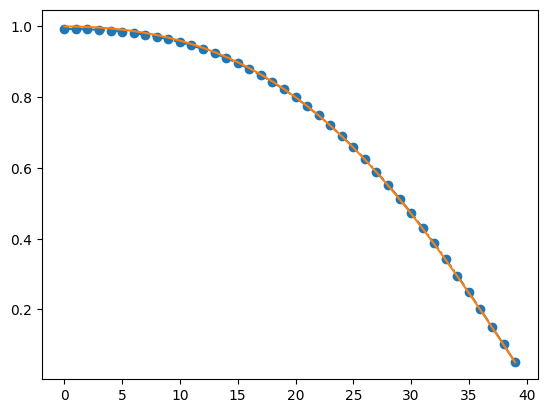

In [18]:
plt.plot(Utensor0[:,0],linestyle='-.',marker='o')
plt.plot(v1)
N,np.sqrt(np.sum((Utensor0[:,1]-v2)**2)*T/N+np.sum((Utensor0[:,0]-v1)**2)*T/N)

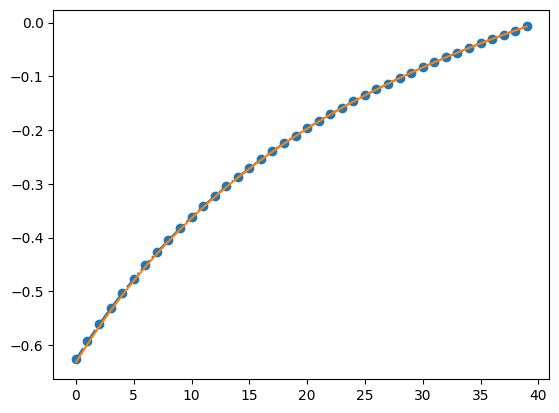

In [19]:
plt.plot(Utensor0[:,1],linestyle='-.',marker='o')
plt.plot(v2)

# SGD

In [20]:
### 
N=40
K=40**2#int(0.3*N) #3*N**2 #N**2
bsize=N
sigma_in=0.5
sde=SDE1(T=1.0, σ=sigma_in, N=N,batch_size=bsize)
YZs=YZSampler(T=1.0,σ=sigma_in,N=N,batch_size=bsize)

v1,v2=sde.Uvec()

time_start=time.time()
Utensor0=sde.init_utensor1()
for k in range(1,K+1): 
   # xlist1,wlist1=sde.generate_SDE_Horder(Utensor0)
    xlist1,wlist1=sde.generate_SDE(Utensor0)
    ylist1, zlist1=YZs.YZ(xlist1,Utensor0, wlist1)
    gradu=YZs.gradU1(xlist1,ylist1, zlist1,Utensor0)

    Utensor0=Utensor0-1.0/k*gradu
time_end=time.time()
time_end-time_start

0.8495779037475586

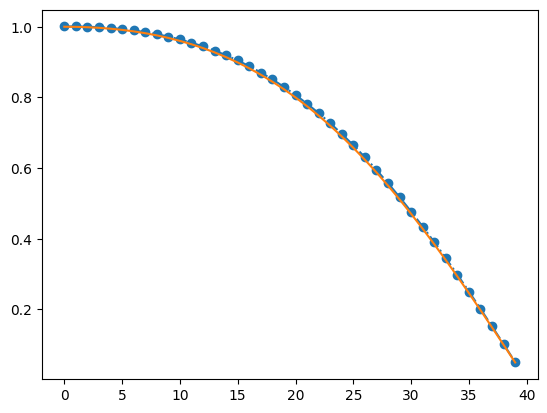

In [23]:
plt.plot(Utensor0[:,0],linestyle='-.',marker='o')
plt.plot(v1)

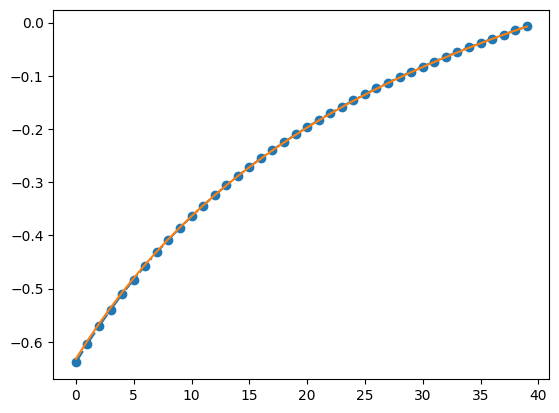

In [21]:
plt.plot(Utensor0[:,1],linestyle='-.',marker='o')
plt.plot(v2)
#df_uncontrolled_sgd=pd.DataFrame(Utensor0) 
#df_uncontrolled_sgd.to_csv('assets_figures/uncontrolled_sgd.csv', index=False)

#df_uncontrolled_exact=pd.DataFrame(np.vstack([v1,v2]).T)
#df_uncontrolled_exact.to_csv('assets_figures/uncontrolled_exact_sgd.csv', index=False)

In [22]:
np.max(np.abs(Utensor0[:,0]-v1)),np.max(np.abs(Utensor0[:,1]-v2))
np.sqrt(np.sum((Utensor0[:,1]-v2)**2)*T/N+np.sum((Utensor0[:,0]-v1)**2)*T/N)

0.005595902321230583